https://bit.ly/FEML-5-PROB

# Влияние предобработки данных на модель

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [2]:
# Создаём сэмпл
n_samples = 1000

np.random.seed(9)
age_owner = np.random.choice(90, n_samples) + 21
length = np.random.choice(120, n_samples) + 15
width = np.random.choice(80, n_samples) + 10

price = length * width * 100 + 126

data = pd.DataFrame({
    'age_owner': age_owner,
    'length': length,
    'width': width,
    'price': price
})
data.head(5)

,age_owner,length,width,price
0,75,57,70,399126
1,77,39,60,234126
2,43,30,36,108126
3,86,30,68,204126
4,43,41,52,213326


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age_owner  1000 non-null   int64
 1   length     1000 non-null   int64
 2   width      1000 non-null   int64
 3   price      1000 non-null   int64
dtypes: int64(4)
memory usage: 31.4 KB


In [4]:
data.describe()

,age_owner,length,width,price
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,65.461000,74.375000,50.207000,3.709868e+05
std,25.728981,33.975708,22.682342,2.480216e+05
min,21.000000,15.000000,10.000000,2.212600e+04
25%,43.000000,45.000000,30.000000,1.681010e+05
50%,65.000000,73.000000,51.000000,3.106260e+05
75%,88.000000,103.000000,69.000000,5.228010e+05
max,110.000000,134.000000,89.000000,1.139126e+06


In [13]:
data.describe(percentiles=[0.1, 0.2, 0.9])

,age_owner,length,width,price,mult
count,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000
mean,65.461000,74.375000,50.207000,3.709868e+05,3708.608000
std,25.728981,33.975708,22.682342,2.480216e+05,2480.216004
min,21.000000,15.000000,10.000000,2.212600e+04,220.000000
10%,30.000000,28.000000,18.000000,1.000260e+05,999.000000
20%,38.000000,39.800000,26.000000,1.431260e+05,1430.000000
50%,65.000000,73.000000,51.000000,3.106260e+05,3105.000000
90%,102.000000,123.000000,81.000000,7.451960e+05,7450.700000
max,110.000000,134.000000,89.000000,1.139126e+06,11390.000000


<Axes: >

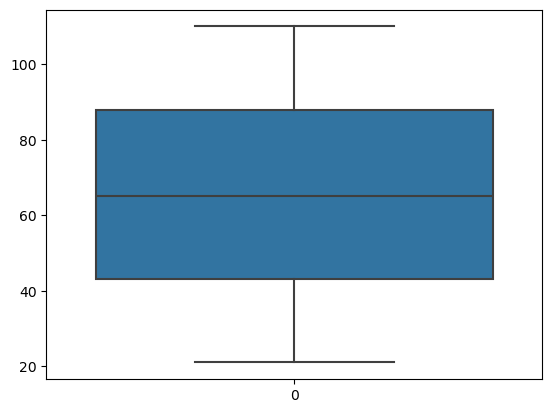

In [17]:
sns.boxplot(data.age_owner)

<Axes: >

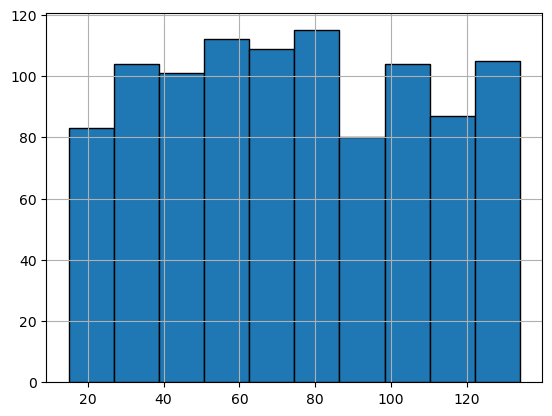

In [19]:
data['length'].hist(bins=10,edgecolor='black')

In [5]:
data['length'].value_counts()

length
27     15
44     15
55     15
129    14
39     13
       ..
116     4
114     4
18      4
109     4
62      4
Name: count, Length: 120, dtype: int64

In [21]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
X = data[['age_owner', 'length', 'width']]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

reg = LinearRegression().fit(X_train, y_train)
print('Weights: {}'.format(reg.coef_))
print('Bias: {}'.format(reg.intercept_))

pred_values = reg.predict(X_test)
print('Error: {}'.format(mean_absolute_error(pred_values, y_test)))

Weights: [-200.43347596 5098.3113772  7431.83917946]
Bias: -370563.36831738445
Error: 52831.38441145646


In [7]:
y.median()

310626.0

In [22]:
X = data[['length', 'width']]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)


reg = LinearRegression().fit(X_train, y_train)
reg = LinearRegression().fit(X_train, y_train)
print('Weights: {}'.format(reg.coef_))
print('Bias: {}'.format(reg.intercept_))

pred_values = reg.predict(X_test)
print('Error: {}'.format(mean_absolute_error(pred_values, y_test)))

Weights: [5139.22504451 7387.0072756 ]
Bias: -379940.7099221582
Error: 57274.76230403326


In [9]:
# Создаем новый признак
data['mult'] = data['length'] * data['width']
data.head(5)

,age_owner,length,width,price,mult
0,75,57,70,399126,3990
1,77,39,60,234126,2340
2,43,30,36,108126,1080
3,86,30,68,204126,2040
4,43,41,52,213326,2132


In [10]:
X = data[['mult']]
y = data['price']
reg = LinearRegression().fit(X, y)
print('Weights: {}'.format(reg.coef_))
print('Bias: {}'.format(reg.intercept_))

pred_values = reg.predict(X)
print('Error: {}'.format(mean_absolute_error(pred_values, y)))

Weights: [100.]
Bias: 126.00000000023283
Error: 1.3966564438305795e-10


In [11]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    # include_bias=False,
    # interaction_only=True
)
X = poly.fit_transform(data[['age_owner', 'length', 'width']])
y = data['price']

poly.get_feature_names_out()

array(['1', 'age_owner', 'length', 'width', 'age_owner^2',
       'age_owner length', 'age_owner width', 'length^2', 'length width',
       'width^2'], dtype=object)

In [12]:
reg_poly = LinearRegression().fit(X, y)
print('Weights: {}'.format(reg_poly.coef_))
print('Bias: {}'.format(reg_poly.intercept_))

pred_values = reg_poly.predict(X)
print('Error: {}'.format(mean_absolute_error(pred_values, y)))

Weights: [ 0.00000000e+00 -1.59697308e-12  5.35304904e-12  3.18904565e-12
  2.89208861e-14 -6.31500331e-14 -1.13582579e-15 -1.15215522e-14
  1.00000000e+02  4.92183781e-14]
Bias: 125.99999999959255
Error: 1.869702828116715e-10


# **Дополнительные материалы**
1. Типы данных https://youtu.be/c4Cg3TUIH0E 
2. Метрика ROC-AUC https://youtu.be/v6PPG8J_Egs
3. Метрика F1-score https://youtu.be/PeE3Fkt5W3Q
4. Масштабирование данных (StandartScaler, MinMaxScaler) https://youtu.be/XsuCOfpf8Ic